In [21]:
from pathlib import Path



import pandas as pd



pd.set_option('display.max_columns', 50)

pd.set_option('display.width', 140)



PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():

    PROJECT_ROOT = PROJECT_ROOT.parent



DATA_DIR = PROJECT_ROOT / 'data'

RESULTS_DIR = PROJECT_ROOT / 'resultados'

RESULTS_DIR.mkdir(exist_ok=True)



SITE_FILES = {

    'Virgen': {

        'tdr_path': DATA_DIR / 'datos_combinados_finales_Virgen.csv',

        'smap_path': DATA_DIR / 'SMAP_Virgen_timeseries.csv',

    },

    'Chirimachaya': {

        'tdr_path': DATA_DIR / 'datos_combinados_finales_Chirimachay.csv',

        'smap_path': DATA_DIR / 'SMAP_Chirimachaya_timeseries.csv',

    },

}





def load_tdr_daily(site_name, tdr_path):

    tdr = pd.read_csv(tdr_path, parse_dates=['TIMESTAMP'])

    tdr['Date'] = tdr['TIMESTAMP'].dt.normalize()



    daily = (

        tdr.groupby('Date', as_index=False)

        .agg(

            tdr_vwc_mean=('VW_Avg', 'mean'),

            tdr_vwc_std=('VW_Avg', 'std'),

            tdr_samples=('VW_Avg', 'size'),

        )

        .sort_values('Date')

    )

    daily['site'] = site_name

    return daily





def load_smap_daily(site_name, smap_path):

    smap = pd.read_csv(smap_path, parse_dates=['timestamp'])

    smap['Date'] = smap['timestamp'].dt.normalize()



    daily = (

        smap.groupby('Date', as_index=False)

        .agg(

            smap_soil_moisture_mean=('soil_moisture', 'mean'),

            smap_samples=('soil_moisture', 'size'),

        )

        .sort_values('Date')

    )

    daily['site'] = site_name

    return daily





def prepare_site_timeseries(site_name, paths):

    tdr_daily = load_tdr_daily(site_name, paths['tdr_path'])

    smap_daily = load_smap_daily(site_name, paths['smap_path'])



    prepared = (

        tdr_daily.merge(smap_daily, on=['site', 'Date'], how='outer')

        .sort_values(['site', 'Date'])

        .reset_index(drop=True)

    )

    prepared['has_tdr'] = prepared['tdr_vwc_mean'].notna()

    prepared['has_smap'] = prepared['smap_soil_moisture_mean'].notna()

    prepared['has_overlap'] = prepared['has_tdr'] & prepared['has_smap']

    prepared['tdr_minus_smap'] = prepared['tdr_vwc_mean'] - prepared['smap_soil_moisture_mean']

    return prepared





prepared_sites = [prepare_site_timeseries(site_name, paths) for site_name, paths in SITE_FILES.items()]

prepared_daily = pd.concat(prepared_sites, ignore_index=True)

prepared_overlap = prepared_daily.loc[prepared_daily['has_overlap']].copy()



site_summary = (

    prepared_daily.groupby('site', as_index=False)

    .agg(

        date_start=('Date', 'min'),

        date_end=('Date', 'max'),

        tdr_days=('has_tdr', 'sum'),

        smap_days=('has_smap', 'sum'),

        overlap_days=('has_overlap', 'sum'),

    )

)



prepared_daily_path = RESULTS_DIR / 'comparison_quinuas_daily_prepared_all_dates.csv'

prepared_overlap_path = RESULTS_DIR / 'comparison_quinuas_daily_prepared_overlap.csv'

site_summary_path = RESULTS_DIR / 'comparison_quinuas_daily_summary.csv'



prepared_daily.to_csv(prepared_daily_path, index=False)

prepared_overlap.to_csv(prepared_overlap_path, index=False)

site_summary.to_csv(site_summary_path, index=False)



print(f'Project root: {PROJECT_ROOT}')

print(f'Prepared daily table saved to: {prepared_daily_path}')

print(f'Overlap-only table saved to: {prepared_overlap_path}')

print(f'Summary table saved to: {site_summary_path}')

print()

print(site_summary)

print()

prepared_overlap.head()


Project root: c:\Bachelorarbeit\NewSG
Prepared daily table saved to: c:\Bachelorarbeit\NewSG\resultados\comparison_quinuas_daily_prepared_all_dates.csv
Overlap-only table saved to: c:\Bachelorarbeit\NewSG\resultados\comparison_quinuas_daily_prepared_overlap.csv
Summary table saved to: c:\Bachelorarbeit\NewSG\resultados\comparison_quinuas_daily_summary.csv

           site date_start   date_end  tdr_days  smap_days  overlap_days
0  Chirimachaya 2015-01-01 2025-10-24      3908       3860          3818
1        Virgen 2015-01-01 2025-12-31      3863       3860          3705



,Date,tdr_vwc_mean,tdr_vwc_std,tdr_samples,site,smap_soil_moisture_mean,smap_samples,has_tdr,has_smap,has_overlap,tdr_minus_smap
89,2015-03-31,0.601830,0.000949,288.0,Virgen,0.341076,8.0,True,True,True,0.260754
90,2015-04-01,0.601847,0.000360,288.0,Virgen,0.338291,8.0,True,True,True,0.263556
91,2015-04-02,0.601042,0.002008,288.0,Virgen,0.337066,8.0,True,True,True,0.263975
92,2015-04-03,0.605809,0.000523,288.0,Virgen,0.337142,8.0,True,True,True,0.268667
93,2015-04-04,0.601715,0.001506,288.0,Virgen,0.334078,8.0,True,True,True,0.267637


Time-series figure saved to: c:\Bachelorarbeit\NewSG\resultados\comparison_quinuas_timeseries_by_site.png


,site,plot_start,plot_end,plot_days
0,Chirimachaya,2015-03-31,2025-10-23,3860
1,Virgen,2015-03-31,2025-10-23,3860


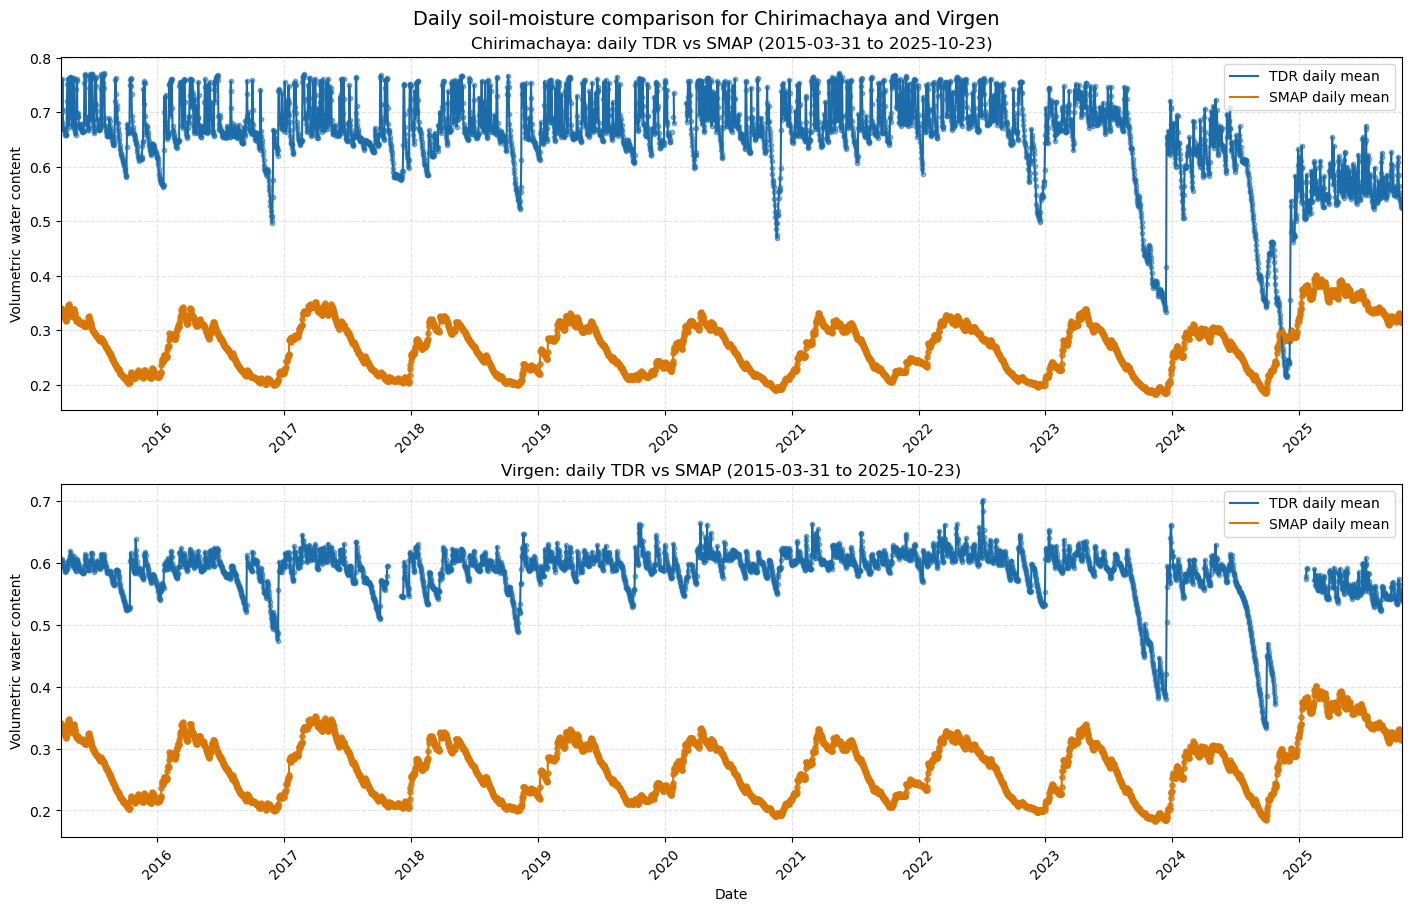

In [22]:
import matplotlib.dates as mdates

import matplotlib.pyplot as plt



site_order = ['Chirimachaya', 'Virgen']

plot_colors = {

    'TDR daily mean': '#1b6ca8',

    'SMAP daily mean': '#d97706',

}



fig, axes = plt.subplots(

    nrows=len(site_order),

    ncols=1,

    figsize=(14, 9),

    sharex=False,

    constrained_layout=True,

)



if len(site_order) == 1:

    axes = [axes]



plot_ranges = []



for axis, site_name in zip(axes, site_order):

    site_all = prepared_daily.loc[prepared_daily['site'] == site_name].copy()

    site_overlap = prepared_overlap.loc[prepared_overlap['site'] == site_name].copy()



    if site_overlap.empty:

        axis.text(0.5, 0.5, f'No overlapping TDR and SMAP dates for {site_name}', ha='center', va='center')

        axis.set_title(site_name)

        axis.set_axis_off()

        continue



    overlap_start = site_overlap['Date'].min()

    overlap_end = site_overlap['Date'].max()

    site_window = site_all.loc[(site_all['Date'] >= overlap_start) & (site_all['Date'] <= overlap_end)].copy()



    axis.plot(

        site_window['Date'],

        site_window['tdr_vwc_mean'],

        color=plot_colors['TDR daily mean'],

        linewidth=1.5,

        label='TDR daily mean',

    )

    axis.scatter(

        site_window['Date'],

        site_window['tdr_vwc_mean'],

        color=plot_colors['TDR daily mean'],

        s=10,

        alpha=0.5,

    )



    axis.plot(

        site_window['Date'],

        site_window['smap_soil_moisture_mean'],

        color=plot_colors['SMAP daily mean'],

        linewidth=1.5,

        label='SMAP daily mean',

    )

    axis.scatter(

        site_window['Date'],

        site_window['smap_soil_moisture_mean'],

        color=plot_colors['SMAP daily mean'],

        s=14,

        alpha=0.8,

    )



    axis.set_xlim(overlap_start, overlap_end)

    axis.set_title(

        f"{site_name}: daily TDR vs SMAP ({overlap_start:%Y-%m-%d} to {overlap_end:%Y-%m-%d})"

    )

    axis.set_ylabel('Volumetric water content')

    axis.grid(True, linestyle='--', alpha=0.35)

    axis.legend(loc='upper right')

    axis.xaxis.set_major_locator(mdates.YearLocator())

    axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    axis.tick_params(axis='x', labelbottom=True, labelrotation=45)



    plot_ranges.append(

        {

            'site': site_name,

            'plot_start': overlap_start,

            'plot_end': overlap_end,

            'plot_days': len(site_window),

        }

    )



axes[-1].set_xlabel('Date')



figure_path = RESULTS_DIR / 'comparison_quinuas_timeseries_by_site.png'

fig.suptitle('Daily soil-moisture comparison for Chirimachaya and Virgen', fontsize=14)

fig.savefig(figure_path, dpi=200, bbox_inches='tight')



plot_range_summary = pd.DataFrame(plot_ranges)

print(f'Time-series figure saved to: {figure_path}')

plot_range_summary


Weekly local-vs-SMAP z-score table saved to: c:\Bachelorarbeit\NewSG\resultados\comparison_quinuas_local_vs_smap_weekly_zscores.csv
Weekly local-vs-SMAP z-score figure saved to: c:\Bachelorarbeit\NewSG\resultados\comparison_quinuas_local_vs_smap_weekly_zscores.png



,site,plot_start,plot_end,local_weeks,smap_weeks
0,Chirimachaya,2015-01-04,2025-10-26,561,552
1,Virgen,2015-01-04,2026-01-04,556,552


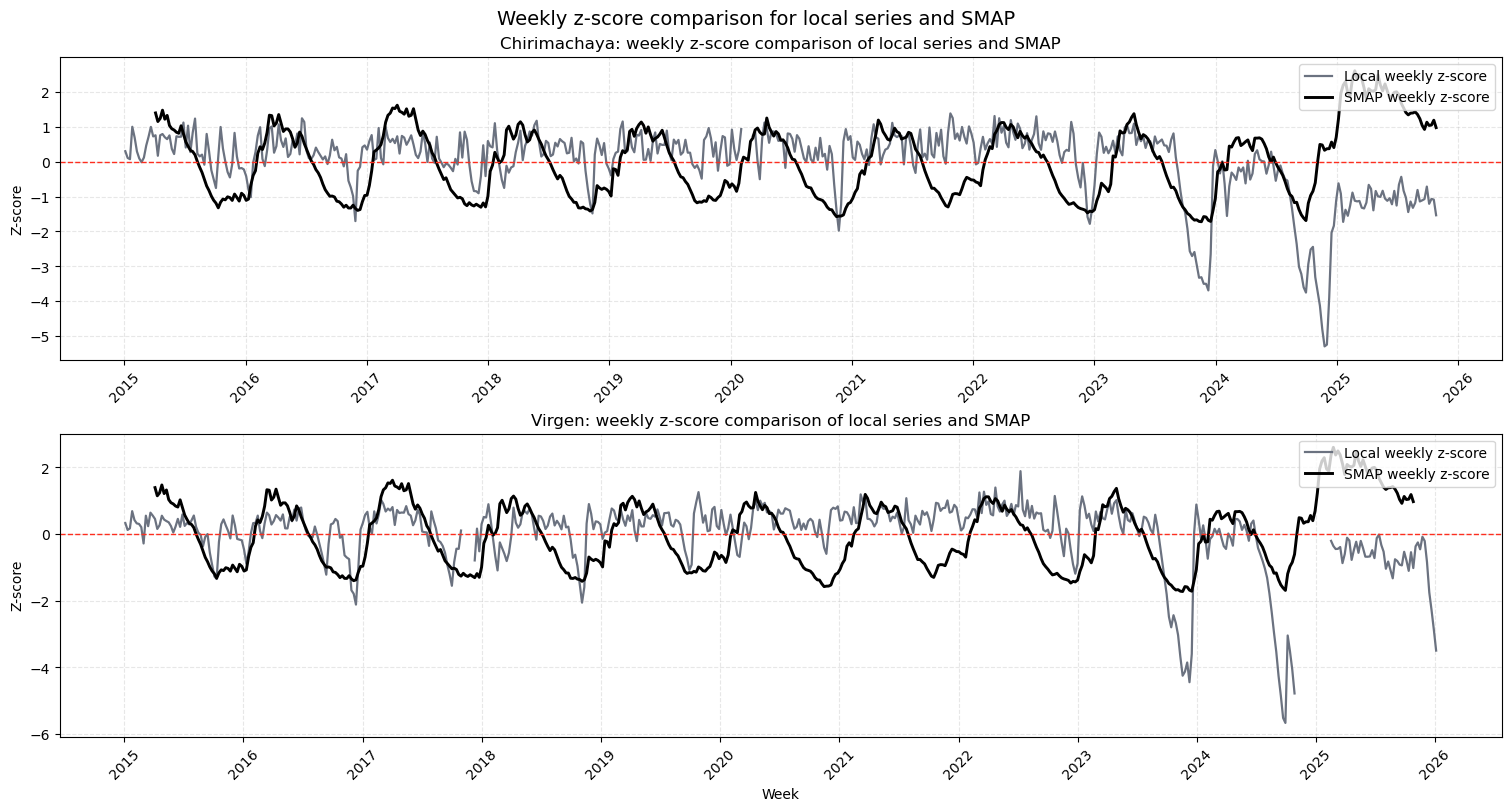

In [28]:
import matplotlib.dates as mdates

import matplotlib.pyplot as plt



zscore_sites = ['Chirimachaya', 'Virgen']

weekly_tables = []





def zscore_series(series):

    series_std = series.std()

    if pd.isna(series_std) or series_std == 0:

        return pd.Series(pd.NA, index=series.index, dtype='float64')

    return (series - series.mean()) / series_std





def load_site_weekly_zscores(site_name, tdr_path, smap_path):

    tdr = pd.read_csv(tdr_path, parse_dates=['TIMESTAMP'])

    smap = pd.read_csv(smap_path, parse_dates=['timestamp'])



    tdr_weekly = (

        tdr.groupby(pd.Grouper(key='TIMESTAMP', freq='W-SUN'))['VW_Avg']

        .mean()

        .reset_index()

        .rename(columns={'TIMESTAMP': 'Week', 'VW_Avg': 'local_vwc_mean'})

        .sort_values('Week')

    )

    tdr_weekly['local_z_score'] = zscore_series(tdr_weekly['local_vwc_mean'])

    tdr_weekly['site'] = site_name



    smap_weekly = (

        smap.groupby(pd.Grouper(key='timestamp', freq='W-SUN'))['soil_moisture']

        .mean()

        .reset_index()

        .rename(columns={'timestamp': 'Week', 'soil_moisture': 'smap_soil_moisture_mean'})

        .sort_values('Week')

    )

    smap_weekly['smap_z_score'] = zscore_series(smap_weekly['smap_soil_moisture_mean'])

    smap_weekly['site'] = site_name



    comparison = tdr_weekly.merge(

        smap_weekly[['site', 'Week', 'smap_soil_moisture_mean', 'smap_z_score']],

        on=['site', 'Week'],

        how='outer',

    ).sort_values('Week')

    return comparison





for site_name in zscore_sites:

    weekly_tables.append(

        load_site_weekly_zscores(

            site_name,

            SITE_FILES[site_name]['tdr_path'],

            SITE_FILES[site_name]['smap_path'],

        )

    )



site_weekly_zscores = pd.concat(weekly_tables, ignore_index=True)

site_weekly_zscores_path = RESULTS_DIR / 'comparison_quinuas_local_vs_smap_weekly_zscores.csv'

site_weekly_zscores.to_csv(site_weekly_zscores_path, index=False)



fig, axes = plt.subplots(

    nrows=len(zscore_sites),

    ncols=1,

    figsize=(15, 8),

    sharex=False,

    constrained_layout=True,

)



if len(zscore_sites) == 1:

    axes = [axes]



plot_summary_rows = []



for axis, site_name in zip(axes, zscore_sites):

    site_weekly_data = site_weekly_zscores.loc[site_weekly_zscores['site'] == site_name].copy()



    axis.plot(

        site_weekly_data['Week'],

        site_weekly_data['local_z_score'],

        linewidth=1.6,

        color='#6b7280',

        label='Local weekly z-score',

    )

    axis.plot(

        site_weekly_data['Week'],

        site_weekly_data['smap_z_score'],

        linewidth=2.1,

        color='black',

        label='SMAP weekly z-score',

    )



    axis.axhline(0, color="#fd2e1f", linestyle='--', linewidth=1.0)

    axis.set_title(f'{site_name}: weekly z-score comparison of local series and SMAP')

    axis.set_ylabel('Z-score')

    axis.grid(True, linestyle='--', alpha=0.3)

    axis.xaxis.set_major_locator(mdates.YearLocator())

    axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    axis.tick_params(axis='x', labelbottom=True, labelrotation=45)

    axis.legend(loc='upper right', frameon=True)



    plot_summary_rows.append(

        {

            'site': site_name,

            'plot_start': site_weekly_data['Week'].min(),

            'plot_end': site_weekly_data['Week'].max(),

            'local_weeks': site_weekly_data['local_z_score'].notna().sum(),

            'smap_weeks': site_weekly_data['smap_z_score'].notna().sum(),

        }

    )



axes[-1].set_xlabel('Week')



zscore_figure_path = RESULTS_DIR / 'comparison_quinuas_local_vs_smap_weekly_zscores.png'

fig.suptitle('Weekly z-score comparison for local series and SMAP', fontsize=14)

fig.savefig(zscore_figure_path, dpi=200, bbox_inches='tight')



zscore_plot_summary = pd.DataFrame(plot_summary_rows)

print(f'Weekly local-vs-SMAP z-score table saved to: {site_weekly_zscores_path}')

print(f'Weekly local-vs-SMAP z-score figure saved to: {zscore_figure_path}')

print()

zscore_plot_summary


Regression summary saved to: c:\Bachelorarbeit\NewSG\resultados\comparison_quinuas_regression_summary.csv
Monthly bias-by-month summary saved to: c:\Bachelorarbeit\NewSG\resultados\comparison_quinuas_monthly_bias_by_month.csv
Regression figure saved to: c:\Bachelorarbeit\NewSG\resultados\comparison_quinuas_regression_swapped_axes.png
Monthly bias figure saved to: c:\Bachelorarbeit\NewSG\resultados\comparison_quinuas_monthly_bias_by_month.png



,site,overlap_days,slope,intercept,pearson_r,r_squared,rmse,mae,mean_bias_smap_minus_tdr
0,Chirimachaya,3818,0.080367,0.216928,0.140009,0.019603,0.392246,0.381916,-0.381334
1,Virgen,3705,0.370089,0.052246,0.328168,0.107694,0.320094,0.315723,-0.315723


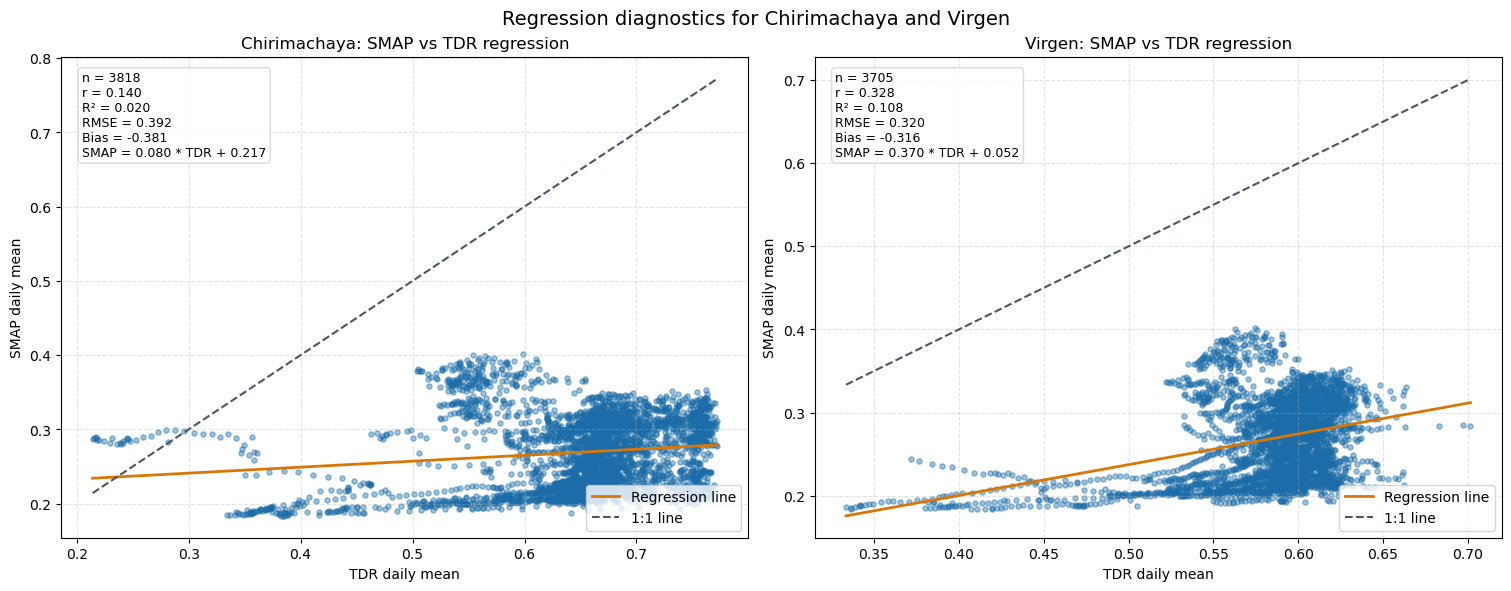

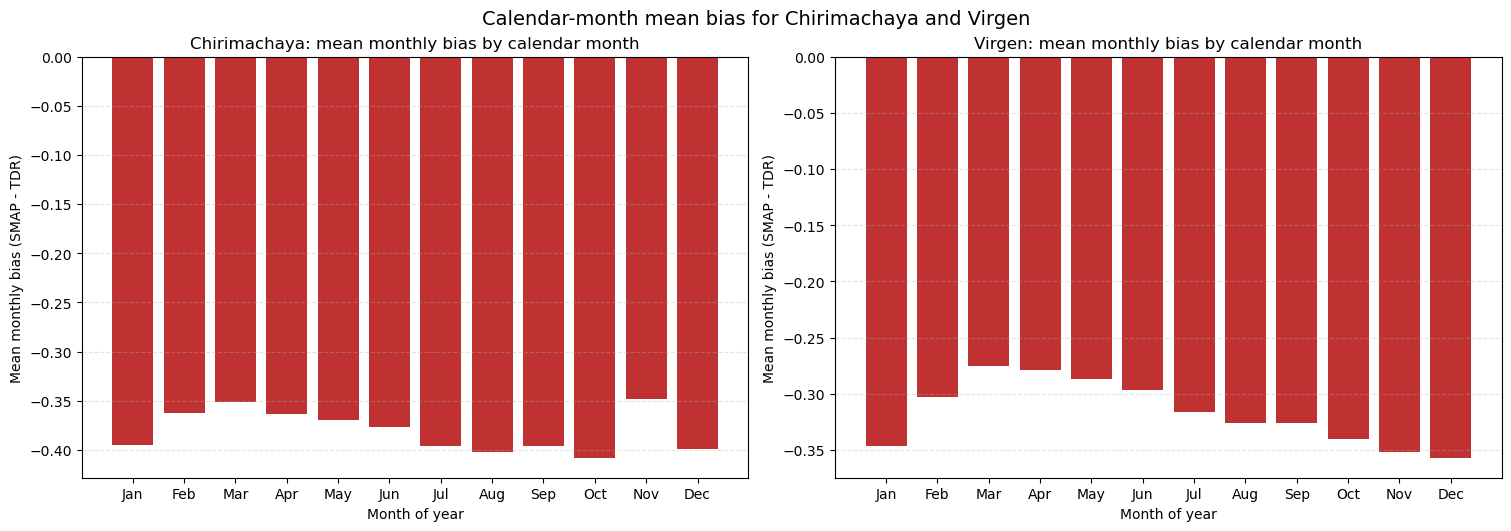

In [24]:
import calendar

import numpy as np

import matplotlib.pyplot as plt



analysis_sites = ['Chirimachaya', 'Virgen']

regression_rows = []

monthly_bias_tables = []



regression_fig, regression_axes = plt.subplots(

    nrows=1,

    ncols=len(analysis_sites),

    figsize=(15, 5.8),

    constrained_layout=True,

)



bias_fig, bias_axes = plt.subplots(

    nrows=1,

    ncols=len(analysis_sites),

    figsize=(15, 5.2),

    constrained_layout=True,

)



if len(analysis_sites) == 1:

    regression_axes = [regression_axes]

    bias_axes = [bias_axes]



for column_index, site_name in enumerate(analysis_sites):

    site_overlap = prepared_overlap.loc[prepared_overlap['site'] == site_name].copy()



    if site_overlap.empty:

        regression_axes[column_index].text(0.5, 0.5, f'No overlap data for {site_name}', ha='center', va='center')

        regression_axes[column_index].set_axis_off()

        bias_axes[column_index].text(0.5, 0.5, f'No monthly bias data for {site_name}', ha='center', va='center')

        bias_axes[column_index].set_axis_off()

        continue



    x = site_overlap['tdr_vwc_mean'].to_numpy()

    y = site_overlap['smap_soil_moisture_mean'].to_numpy()

    slope, intercept = np.polyfit(x, y, 1)

    correlation = np.corrcoef(x, y)[0, 1]

    r_squared = correlation ** 2

    rmse = np.sqrt(np.mean((y - x) ** 2))

    mae = np.mean(np.abs(y - x))

    mean_bias = np.mean(y - x)



    regression_rows.append(

        {

            'site': site_name,

            'overlap_days': len(site_overlap),

            'slope': slope,

            'intercept': intercept,

            'pearson_r': correlation,

            'r_squared': r_squared,

            'rmse': rmse,

            'mae': mae,

            'mean_bias_smap_minus_tdr': mean_bias,

        }

    )



    scatter_axis = regression_axes[column_index]

    scatter_axis.scatter(x, y, s=14, alpha=0.42, color='#1b6ca8')

    x_line = np.linspace(x.min(), x.max(), 100)

    scatter_axis.plot(x_line, slope * x_line + intercept, color='#d97706', linewidth=2, label='Regression line')

    scatter_axis.plot(x_line, x_line, color='#4b5563', linestyle='--', linewidth=1.5, label='1:1 line')

    scatter_axis.set_title(f'{site_name}: SMAP vs TDR regression')

    scatter_axis.set_xlabel('TDR daily mean')

    scatter_axis.set_ylabel('SMAP daily mean')

    scatter_axis.grid(True, linestyle='--', alpha=0.35)

    scatter_axis.legend(loc='lower right', frameon=True)

    scatter_axis.text(

        0.03,

        0.97,

        '\n'.join([

            f'n = {len(site_overlap)}',

            f'r = {correlation:.3f}',

            f'R² = {r_squared:.3f}',

            f'RMSE = {rmse:.3f}',

            f'Bias = {mean_bias:.3f}',

            f'SMAP = {slope:.3f} * TDR + {intercept:.3f}',

        ]),

        transform=scatter_axis.transAxes,

        va='top',

        ha='left',

        fontsize=9,

        bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.85, 'edgecolor': '#d1d5db'},

    )



    site_overlap['month_number'] = site_overlap['Date'].dt.month

    site_overlap['bias_smap_minus_tdr'] = site_overlap['smap_soil_moisture_mean'] - site_overlap['tdr_vwc_mean']

    monthly_bias = (

        site_overlap.groupby('month_number', as_index=False)

        .agg(

            monthly_bias_mean=('bias_smap_minus_tdr', 'mean'),

            sample_days=('bias_smap_minus_tdr', 'size'),

        )

        .sort_values('month_number')

    )

    monthly_bias['month_name'] = monthly_bias['month_number'].map(lambda month: calendar.month_abbr[month])

    monthly_bias['site'] = site_name

    monthly_bias_tables.append(monthly_bias)



    bias_axis = bias_axes[column_index]

    bar_colors = ['#b91c1c' if value < 0 else '#0f766e' for value in monthly_bias['monthly_bias_mean']]

    bias_axis.bar(monthly_bias['month_name'], monthly_bias['monthly_bias_mean'], color=bar_colors, alpha=0.9)

    bias_axis.axhline(0, color='#4b5563', linestyle='--', linewidth=1.2)

    bias_axis.set_title(f'{site_name}: mean monthly bias by calendar month')

    bias_axis.set_xlabel('Month of year')

    bias_axis.set_ylabel('Mean monthly bias (SMAP - TDR)')

    bias_axis.grid(True, axis='y', linestyle='--', alpha=0.35)



regression_summary = pd.DataFrame(regression_rows)

monthly_bias_summary = pd.concat(monthly_bias_tables, ignore_index=True)



regression_summary_path = RESULTS_DIR / 'comparison_quinuas_regression_summary.csv'

monthly_bias_summary_path = RESULTS_DIR / 'comparison_quinuas_monthly_bias_by_month.csv'

regression_figure_path = RESULTS_DIR / 'comparison_quinuas_regression_swapped_axes.png'

monthly_bias_figure_path = RESULTS_DIR / 'comparison_quinuas_monthly_bias_by_month.png'



regression_summary.to_csv(regression_summary_path, index=False)

monthly_bias_summary.to_csv(monthly_bias_summary_path, index=False)

regression_fig.suptitle('Regression diagnostics for Chirimachaya and Virgen', fontsize=14)

bias_fig.suptitle('Calendar-month mean bias for Chirimachaya and Virgen', fontsize=14)

regression_fig.savefig(regression_figure_path, dpi=200, bbox_inches='tight')

bias_fig.savefig(monthly_bias_figure_path, dpi=200, bbox_inches='tight')



print(f'Regression summary saved to: {regression_summary_path}')

print(f'Monthly bias-by-month summary saved to: {monthly_bias_summary_path}')

print(f'Regression figure saved to: {regression_figure_path}')

print(f'Monthly bias figure saved to: {monthly_bias_figure_path}')

print()

regression_summary
